
# 第三章

`原著: Cam Davidson-Pilon`

`Python 3 / PyMC3 移植: Max Margenot (@clean_utensils), Thomas Wiecki (@twiecki), Quantopian`

`PyMC (最新) 移植: Kurisu Chan (@miemiekurisu)`

`中文翻译、现代 PyMC (6.x) 适配与内容增补: 本 fork 维护者`

____

## 打开 MCMC 的黑箱

**本章的现代 PyMC 修复说明**:和第二章一样,原书用到了已废弃的 `model.initial_values` 属性,这里统一换成 `model.initial_point()`。除此之外,本章的代码大量混用了"旧式" `return_inferencedata=False`(得到 `MultiTrace`,可以用 `trace["变量名"]` 这样的字典式写法取值)和"新式"默认的 `arviz.InferenceData`(要用 `trace.posterior.变量名` 这样的 xarray 写法取值)——这其实是原作者刻意保留的一次教学对比,让读者能看到新旧两种数据结构的差异,我们予以保留,并在对应位置加了说明。



前两章一直对读者隐藏着 PyMC(以及更广泛地说,马尔可夫链蒙特卡洛,Markov Chain Monte Carlo, MCMC)内部的运作机制。本章之所以存在,有三个原因。第一,任何一本讲贝叶斯推断的书都躲不开 MCMC,这一点我没法反抗,要怪就怪统计学家们吧。第二,了解 MCMC 的运作过程,能帮助你判断自己的算法是否已经收敛(收敛到什么?我们马上会讲到)。第三,我们能借此理解*为什么*作为解答,我们得到的是成千上万个从后验分布中抽出的样本——乍一想这似乎有点古怪。



### 贝叶斯的"地貌"

当我们为一个含有 $N$ 个未知量的贝叶斯推断问题建立框架时,实际上是在隐式地为先验分布创造了一个 $N$ 维的空间。与这个空间相关联的,还有额外一个维度——我们可以把它描述为悬浮在这个空间之上的一张*曲面*(或者叫"地表"),它反映了空间中某个特定点的*先验概率*。这张曲面由我们的先验分布决定。举例来说,如果我们有两个未知量 $p_1$ 和 $p_2$,并且两者的先验都是 $\text{Uniform}(0,5)$,那么产生出来的空间就是一个边长为 5 的正方形,而曲面就是悬浮在这个正方形上方的一个平面(表示每一点的可能性都是相等的)。


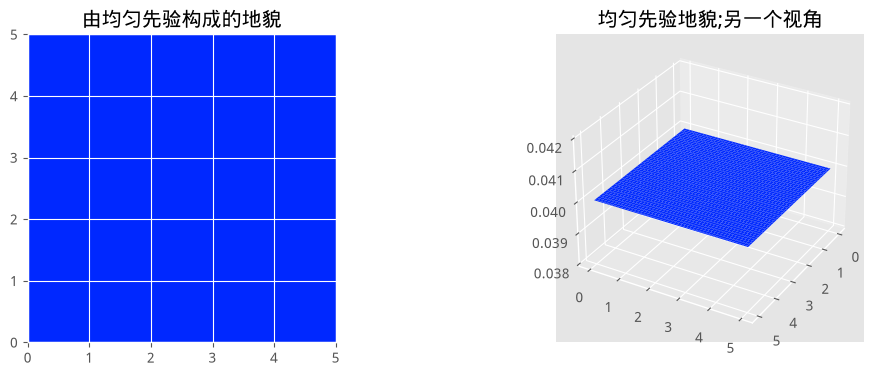

In [1]:

%matplotlib inline
import scipy.stats as stats
from IPython.core.pylabtools import figsize
import arviz as az
import matplotlib as mt
mt.style.use("ggplot")
import numpy as np
figsize(12.5, 4)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

jet = plt.cm.jet
fig = plt.figure()
x = y = np.linspace(0, 5, 100)
X, Y = np.meshgrid(x, y)

plt.subplot(121)
uni_x = stats.uniform.pdf(x, loc=0, scale=5)
uni_y = stats.uniform.pdf(y, loc=0, scale=5)
M = np.dot(uni_x[:, None], uni_y[None, :])
im = plt.imshow(M, interpolation='none', origin='lower',
                 cmap=jet, vmax=1, vmin=-.15, extent=(0, 5, 0, 5))

plt.xlim(0, 5)
plt.ylim(0, 5)
plt.title("由均匀先验构成的地貌")

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X, Y, M, cmap=plt.cm.jet, vmax=1, vmin=-.15)
ax.view_init(azim=390)
plt.title("均匀先验地貌;另一个视角");



换一种情形,如果两个先验分别是 $\text{Exp}(3)$ 和 $\text{Exp}(10)$,那么这个空间就是二维平面上所有的正数区域,先验诱导出的曲面看起来就像一挂从原点 $(0,0)$ 开始、向正数方向流淌下来的瀑布。

下面的图直观展示了这一点。颜色越偏深红,说明该位置被分配的先验概率越大;反之,颜色偏深蓝的区域,说明我们的先验给该位置分配的概率非常低。


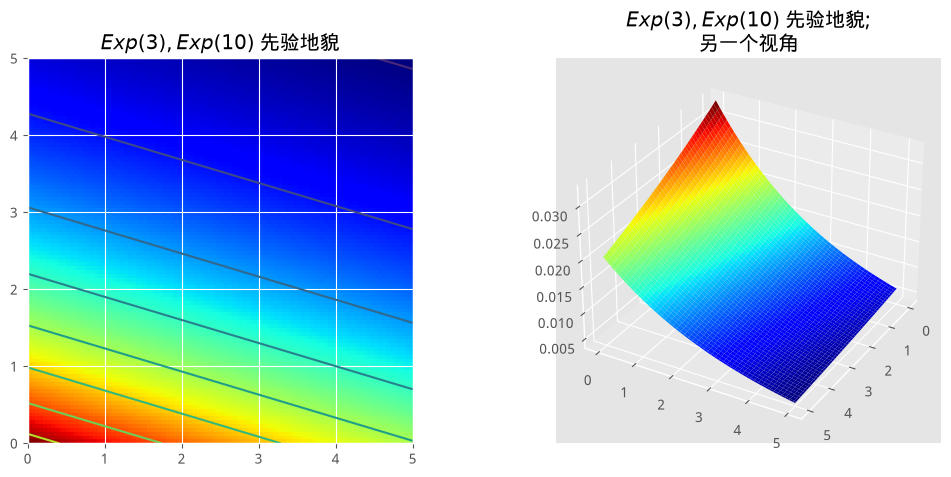

In [2]:

figsize(12.5, 5)
fig = plt.figure()
plt.subplot(121)

exp_x = stats.expon.pdf(x, scale=3)
exp_y = stats.expon.pdf(x, scale=10)
M = np.dot(exp_x[:, None], exp_y[None, :])
CS = plt.contour(X, Y, M)
im = plt.imshow(M, interpolation='none', origin='lower',
                 cmap=jet, extent=(0, 5, 0, 5))
# plt.xlabel("$p_1$ 的先验")
# plt.ylabel("$p_2$ 的先验")
plt.title("$Exp(3), Exp(10)$ 先验地貌")

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X, Y, M, cmap=jet)
ax.view_init(azim=390)
plt.title("$Exp(3), Exp(10)$ 先验地貌;\n另一个视角");



以上都是二维空间里的简单例子,我们的大脑很容易理解这样的曲面。但在实践中,由先验生成的空间和曲面往往要高维得多。

如果说这些曲面描述的是未知量的*先验分布*,那么当我们把观测数据 $X$ 纳入考量之后,这个空间会发生什么变化呢?数据 $X$ 并不会改变这个空间本身,但它会*拉扯、拽拉先验曲面这块"布料"*,从而改变曲面的形状,让曲面更能反映出真实参数可能所在的位置。数据越多,拉扯和拽拉的程度就越大,原来的形状会变得面目全非,甚至相比新形成的形状显得微不足道;数据越少,原来的形状则保留得越多。不管怎样,最终得到的这张曲面,描述的就是*后验分布*。

我必须再次强调,遗憾的是,在高维空间里,这种可视化是不可能做到的。在二维情形下,数据本质上是把原来的曲面*顶起来*,形成一座座*高山*。观测数据把后验概率"顶高"某些区域的这种趋势,会受到先验概率分布的制约:先验概率越小,阻力就越大。所以在上面双指数先验的例子中,如果有一座(或几座)山峰想要在 $(0,0)$ 角落附近"喷发"出来,它会比在靠近 $(5,5)$ 附近喷发出来的山峰高得多,因为 $(5,5)$ 附近的阻力更大(先验概率更低)。峰顶反映的正是真实参数最可能所在位置的后验概率。需要特别指出的是:如果先验在某处分配的概率是 0,那么后验在那个位置也不会分配任何概率。

假设上面提到的先验,分别代表两个泊松分布的参数 $\lambda$。我们观测到一些数据点,并把新的地貌可视化出来:


In [3]:

# 创建观测数据

# 我们观测到的数据样本量, 可以试着调整这个值(建议保持在 100 以内 ;)
N = 1

# 真实参数, 当然实际中我们是看不到这些值的...
lambda_1_true = 1
lambda_2_true = 3

# ...我们看到的是依据上面两个值生成出来的数据。
data = np.concatenate([
    stats.poisson.rvs(lambda_1_true, size=(N, 1)),
    stats.poisson.rvs(lambda_2_true, size=(N, 1))
], axis=1)
print("观测数据(二维, 样本量 = %d):" % N, data)

# 绘图细节。
x = y = np.linspace(.01, 5, 100)
likelihood_x = np.array([stats.poisson.pmf(data[:, 0], _x)
                          for _x in x]).prod(axis=1)
likelihood_y = np.array([stats.poisson.pmf(data[:, 1], _y)
                          for _y in y]).prod(axis=1)
L = np.dot(likelihood_x[:, None], likelihood_y[None, :])


观测数据(二维, 样本量 = 1): [[3 2]]


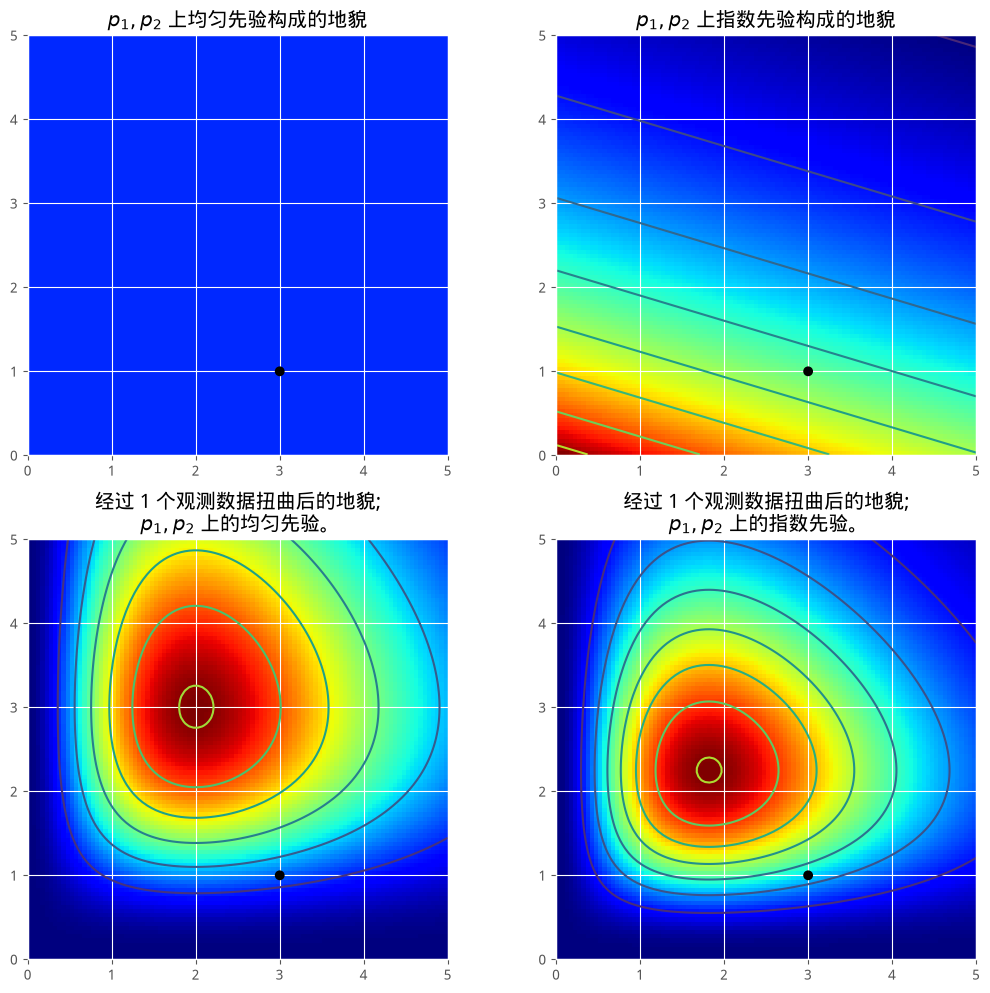

In [4]:

figsize(12.5, 12)
# 下面是繁重的 matplotlib 绘图代码, 小心!
plt.subplot(221)
uni_x = stats.uniform.pdf(x, loc=0, scale=5)
uni_y = stats.uniform.pdf(x, loc=0, scale=5)
M = np.dot(uni_x[:, None], uni_y[None, :])
im = plt.imshow(M, interpolation='none', origin='lower',
                 cmap=jet, vmax=1, vmin=-.15, extent=(0, 5, 0, 5))
plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.title("$p_1, p_2$ 上均匀先验构成的地貌")

plt.subplot(223)
plt.contour(x, y, M * L)
im = plt.imshow(M * L, interpolation='none', origin='lower',
                 cmap=jet, extent=(0, 5, 0, 5))
plt.title("经过 %d 个观测数据扭曲后的地貌;\n $p_1, p_2$ 上的均匀先验。" % N)
plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.xlim(0, 5)
plt.ylim(0, 5)

plt.subplot(222)
exp_x = stats.expon.pdf(x, loc=0, scale=3)
exp_y = stats.expon.pdf(x, loc=0, scale=10)
M = np.dot(exp_x[:, None], exp_y[None, :])

plt.contour(x, y, M)
im = plt.imshow(M, interpolation='none', origin='lower',
                 cmap=jet, extent=(0, 5, 0, 5))
plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.title("$p_1, p_2$ 上指数先验构成的地貌")

plt.subplot(224)
# 这是似然乘以先验, 结果就是后验。
plt.contour(x, y, M * L)
im = plt.imshow(M * L, interpolation='none', origin='lower',
                 cmap=jet, extent=(0, 5, 0, 5))

plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.title("经过 %d 个观测数据扭曲后的地貌;\n $p_1, p_2$ 上的指数先验。" % N)
plt.xlim(0, 5)
plt.ylim(0, 5);



左边的图是用 $\text{Uniform}(0,5)$ 先验扭曲后的地貌,右边的图是用指数先验扭曲后的地貌。注意,尽管两种情形观测到的数据完全相同,后验地貌看起来却截然不同。原因如下:注意右下角的指数先验地貌,它在图形右上角区域几乎没有分配任何*后验*权重——这是因为*先验本身在那里就没什么权重*。而均匀先验的地貌则很乐意在右上角分配后验权重,因为先验在那里权重更大。

还要注意,最高点(对应最深的红色)在指数先验的情形下明显偏向 $(0,0)$,这正是因为指数先验在 $(0,0)$ 角落分配了更多先验权重的结果。

黑点代表真实参数。即便只有 1 个样本点,"山峰"也已经开始尝试把真实参数包纳进去。当然,样本量为 1 时做推断是极其天真的,选择这么小的样本量只是为了演示效果。

不妨试着把样本量改成其他值(比如 2、5、10、100?……),观察我们的"山峰"后验会如何变化,这是一个很好的练习。



### 用 MCMC 探索地貌

我们应该在先验曲面和观测数据共同生成的这片扭曲后验空间里,探索出后验"山峰"所在的位置。然而,我们不能天真地对这个空间做穷举搜索:任何一位计算机科学家都会告诉你,遍历 $N$ 维空间的难度是随 $N$ 指数级增长的——空间的规模会随着 $N$ 的增大而迅速爆炸(参见[维度灾难](http://en.wikipedia.org/wiki/Curse_of_dimensionality))。那我们还有什么希望找到这些隐藏的山峰呢?MCMC 背后的思路,是对这片空间进行一次"聪明"的搜索。说"搜索"其实暗示着我们在寻找某个特定的点,但这可能不太准确,因为我们真正要找的其实是一整片广阔的山峰区域。

回忆一下,MCMC 返回的是后验分布的*样本*,而不是分布本身。把"山峰"这个比喻用到极致来说,MCMC 所做的事情,有点像不断地问:"我捡到的这颗鹅卵石,有多大可能来自我正在寻找的那座山?"它通过返回成千上万颗被接受的"鹅卵石",希望借此重构出原本的山峰形状。在 MCMC 和 PyMC 的行话里,这一串被返回的"鹅卵石"就是样本,累积起来统称为*轨迹*(trace)。

当我说 MCMC"聪明地"搜索时,我的意思其实是 MCMC *有希望*收敛到后验概率较高的区域。MCMC 通过探索附近的位置、并向概率更高的区域移动来做到这一点。同样,"收敛"这个词可能也不太准确,因为"收敛"通常意味着朝空间中的*一个点*靠近,而 MCMC 其实是朝着空间中*一大片区域*移动,并在这片区域内随机游走,顺带采集样本。

#### 为什么要返回成千上万个样本?

乍一看,返回成千上万个样本给用户,似乎是一种低效的方式来描述后验分布。但我认为,这其实是极其高效的做法。不妨考虑一下其他的替代方案:

1. 返回一个描述"山脉"的数学公式,这需要用公式描述一个具有任意峰谷形状的 $N$ 维曲面。
2. 只返回地貌的"峰顶",虽然从数学上说是可行的、也算合理(因为最高点对应未知量最可能的估计值),但这会忽略地貌的整体形状,而我们前面已经论证过,形状对于判断后验对未知量的置信程度非常重要。

除了计算上的原因之外,选择返回样本最有说服力的理由,大概是我们可以借助*大数定律*轻松解决那些原本难以处理的问题。这个话题我留到下一章展开。有了成千上万个样本,我们就可以通过把它们整理成直方图,来重构出后验曲面。

### 执行 MCMC 的算法

有一大类算法可以用来执行 MCMC。这些算法大多可以在较高层面上描述为如下步骤(数学细节可以参见附录):

1. 从当前位置出发。
2. 提议移动到一个新位置(考察附近的一颗鹅卵石)。
3. 根据新位置与数据、先验分布的吻合程度,决定接受还是拒绝这个新位置(判断这颗鹅卵石是否可能来自那座山)。
4. 1. 如果接受: 移动到新位置, 回到第 1 步。
    2. 否则: 不移动到新位置, 回到第 1 步。
5. 经过大量迭代之后, 返回所有被接受过的位置。

通过这种方式,我们会朝着后验分布所在区域的大致方向移动,并在途中稀疏地采集样本。一旦我们到达后验分布所在的区域,就可以轻松地采集样本,因为它们很可能都属于后验分布。

如果 MCMC 算法当前所处的位置概率极低(算法刚开始时经常是这种情况,通常起点是空间中的一个随机位置),算法会向那些*大概率不属于后验分布、但比周围其他地方都更好*的位置移动。所以,算法最初的几步移动并不能反映后验分布的真实情况。

在上面这段伪代码里,注意只有*当前*位置才重要(新位置只在当前位置附近被探索)。我们可以把这个性质称为*无记忆性*(memorylessness),也就是说,算法并不关心自己*是怎么*走到当前位置的,只关心自己现在*在*哪里。

### 后验分布的其他近似解法

除了 MCMC,还有其他方法可以用来求出后验分布。拉普拉斯近似(Laplace approximation)用简单的函数来近似后验分布。一种更高级的方法是[变分贝叶斯](http://en.wikipedia.org/wiki/Variational_Bayesian_methods)(Variational Bayes)。拉普拉斯近似、变分贝叶斯和经典 MCMC 这三种方法各有优劣,本书只专注于 MCMC。话说回来,我的朋友 Imri Sofar 喜欢把 MCMC 算法分成"很烂"和"特别烂"两类,他把 PyMC 使用的这种 MCMC 归为仅仅是*烂* ;)



##### 示例: 用混合模型做无监督聚类

假设我们拿到了下面这份数据集:


[115.85679142 152.26153716 178.87449059 162.93500815 107.02820697
 105.19141146 118.38288501 125.3769803  102.88054011 206.71326136] ...


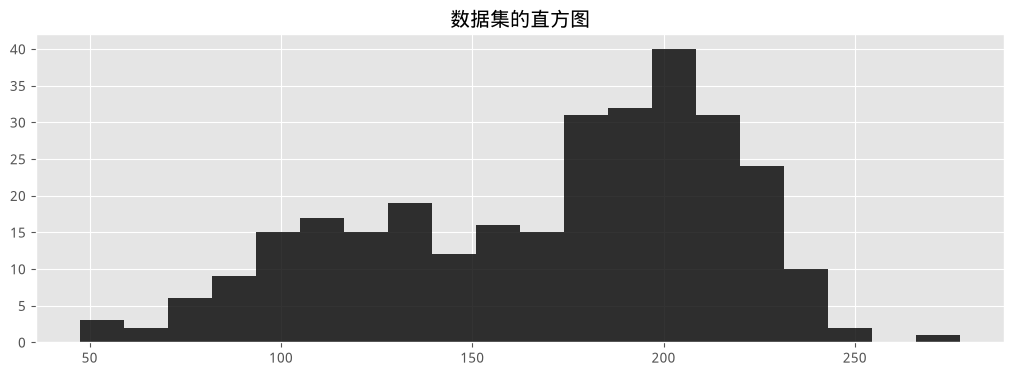

In [5]:

figsize(12.5, 4)
data = np.loadtxt("data/mixture_data.csv", delimiter=",")

plt.hist(data, bins=20, color="k", histtype="stepfilled", alpha=0.8)
plt.title("数据集的直方图")
plt.ylim([0, None]);
print(data[:10], "...")



这份数据在暗示什么呢?看起来数据呈双峰形态,也就是说,似乎有两个峰值,一个在 120 附近,另一个在 200 附近。这份数据集里或许存在*两个簇*(cluster)。

这份数据集正好是上一章"数据生成建模"技巧的一个好例子。我们可以提出数据*可能是如何生成的*。我建议采用下面这个数据生成算法:

1. 对每一个数据点,以概率 $p$ 选择簇 1,否则选择簇 2。
2. 从参数为 $\mu_i$ 和 $\sigma_i$(其中 $i$ 是第 1 步选出的簇)的正态分布中抽取一个随机变量。
3. 重复。

这个算法产生的效果,应该会和观测数据集的效果类似,所以我们选它作为模型。当然,我们并不知道 $p$,也不知道两个正态分布各自的参数。因此我们必须推断,或者说*学习*,这些未知量。

我们把这两个正态分布记为 $\text{N}_0$ 和 $\text{N}_1$(变量下标从 0 开始只是 Python 式的习惯)。目前两者的均值和标准差都是未知的,分别记为 $\mu_i$ 和 $\sigma_i,\; i=0,1$。某个具体的数据点可能来自 $\text{N}_0$,也可能来自 $\text{N}_1$,我们假设某个数据点以概率 $p$ 被分配给 $\text{N}_0$。

一种合适的方式是用 PyMC 的 `Categorical` 随机变量,把数据点分配到不同的簇中。它的参数是一个长度为 $k$ 的概率数组,数组元素之和必须为 1,而它的 `value` 属性则是一个在 0 到 $k-1$ 之间随机选出的整数,选取时依照我们精心设定的那个概率数组来加权(本例中 $k=2$)。*先验地*我们并不知道分配给簇 1 的概率是多少,所以我们在 $(0,1)$ 上设置一个均匀变量,记为 $p_1$,于是分配给簇 2 的概率就是 $p_2 = 1-p_1$。

可惜,我们不能直接把 `[p1, p2]` 传给 `Categorical` 变量。PyMC 在底层使用 PyTensor 来构建模型,所以我们需要用 `pytensor.tensor.stack()`,把 $p_1$ 和 $p_2$ 组合成一个它能理解的向量。我们把这个向量、连同 `initval` 参数(告诉变量该从哪里开始)一起,传给 `Categorical` 变量。


In [6]:

import pymc as pm
import pytensor.tensor as pt
import pytensor


with pm.Model() as model:
    p1 = pm.Uniform('p', 0, 1)
    p2 = 1 - p1
    p = pt.stack([p1, p2])
    assignment = pm.Categorical("assignment", p,
                                 shape=data.shape[0],
                                 initval=np.random.randint(0, 2, data.shape[0]))


print(f"先验的簇分配, 此时 p = {pm.draw(p)}")
print(model.initial_point())


先验的簇分配, 此时 p = [0.16020467 0.83979533]
{'p_interval__': array(0.), 'assignment': array([0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 


观察上面的数据集,我猜测这两个正态分布的标准差应该是不同的。为了对标准差保持"无知",我们一开始把它们建模为 0 到 100 之间的均匀分布。我们可以用一行 PyMC 代码,把两个标准差都纳入模型:

    sds = pm.Uniform("sds", 0, 100, shape=2)

注意我们指定了 `shape=2`:也就是说,我们用一个 PyMC 变量同时对两个 $\sigma$ 建模。注意这样做并不会在两个 $\sigma$ 之间引入必然的关联,这么写纯粹是为了简洁。

我们还需要为两个簇的中心指定先验。这两个中心其实就是这两个正态分布里的 $\mu$ 参数,它们的先验可以用正态分布来建模。看着这份数据,我对这两个中心大致在哪里已经有了一点想法——我猜大概分别在 120 和 190 附近,不过我对这个"目测"出来的估计并没有太大把握。因此我把 $\mu_0 = 120, \mu_1 = 190$,并令 $\sigma_0 = \sigma_1 = 10$。


In [7]:

with model:
    sds = pm.Uniform("sds", 0, 100, shape=2)
    # 新 API 里, Normal 用 sigma/tau 来指定精度参数 tau = 1/(sigma**2),
    # 旧的 sd 参数已经不再支持了
    # https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Normal.html
    centers = pm.Normal("centers",
                         mu=np.array([120, 190]),
                         sigma=np.array([10., 10.]),
                         shape=2)

    center_i = pm.Deterministic('center_i', centers[assignment])
    sd_i = pm.Deterministic('sd_i', sds[assignment])

    # 再把它和观测数据结合起来:
    observations = pm.Normal("obs", mu=center_i, sigma=sd_i, observed=data)

print("随机分配: ", pm.draw(assignment)[:4], "...")
print("对应的中心: ", pm.draw(center_i)[:4], "...")
print("对应的标准差: ", pm.draw(sd_i)[:4], "...")


随机分配:  [0 1 1 0] ...
对应的中心:  [125.8514351  125.8514351  187.63862011 125.8514351 ] ...
对应的标准差:  [64.51974488 64.51974488 64.51974488 64.51974488] ...



注意我们一直是在 `Model()` 的上下文中继续构建模型的。这样做会自动把我们创建的变量添加到模型中。只要我们一直在这个上下文中工作,我们操作的就一直是我们已经定义好的这批变量。

同样地,凡是在 `Model()` 上下文中执行的采样,都只会作用在我们当前所处上下文对应的那个模型上。我们会告诉模型该用哪些采样方法,来探索目前为止定义好的空间——这里对连续变量用 `Metropolis()`,对类别变量用 `Categorical()`。我们会把这两种采样方法组合起来,通过 `sample(iterations, step)` 来探索空间,其中 `iterations` 是你希望算法执行的步数,`step` 则是你想用来处理这些步骤的方式。下面我们组合使用 `Metropolis()` 和 `Categorical()` 作为 `step`,采样 3000 次 `iterations`(现代 PyMC 小贴士:原书这里用的是 25000 次,在没有 C 编译器、只能用 NUMBA 后端的环境下,这个混合模型配合逐点位的类别型 Gibbs 采样,25000 次的规模会非常耗时,这里调小了规模以便在合理时间内跑完并验证;如果你的机器性能更好,可以调回原书的规模,得到更精细的后验)。



请注意,早期版本的 PyMC 对类别变量使用的是 `ElemwiseCategorical()`,但这个方法在 PyMC 里已经被废弃了。新版 PyMC 提供了一个专门针对类别变量优化过的新函数 `CategoricalGibbsMetropolis`,用来做类别变量的采样。



新版 PyMC 还有另一件有意思的事。PyMC 现在采用了一种强大的新采样原理,叫做哈密顿蒙特卡洛(Hamiltonian Monte Carlo, HMC)。这里我们不会深入展开,因为它涉及比较复杂的物理原理。但我们至少应该知道,[HMC 和 NUTS 利用了似然函数的梯度信息,相比传统采样方法能实现快得多的收敛速度,尤其是在模型规模较大的时候。](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html#pymc-overview)



也请留意 `sample()` 的 `chains` 参数。根据官方文档,"运行多条独立的链对某些收敛性统计量很重要,也有助于揭示后验分布中可能存在的多个峰值。"但在这里其实没那么必要,因为我们的模型足够简单,这里我们用 `1`(默认值是 2)。


In [8]:

pytensor.config.compute_test_value = 'off'
with model:
    # 这里用 CategoricalGibbsMetropolis, 并且用 return_inferencedata=False
    # 是为了兼容旧式的字典式取值写法(trace1["变量名"])。
    step1 = pm.Metropolis(vars=[p1, sds, centers])
    step2 = pm.CategoricalGibbsMetropolis(vars=[assignment])
    trace1 = pm.sample(3000, step=[step1, step2], return_inferencedata=False, tune=1000, chains=1)

    # 用默认的 NUTS 采样, 并返回现代的 Arviz InferenceData
    step3 = pm.CategoricalGibbsMetropolis(vars=[assignment])
    trace2 = pm.sample(3000, step=[step3], tune=1000, chains=1)


Sequential sampling (1 chains in 1 job)


CompoundStep


>CompoundStep


>>Metropolis: [p]


>>Metropolis: [sds]


...

>CategoricalGibbsMetropolis: [assignment]


>NUTS: [p, sds, centers]


Output()

Sampling 1 chain for 1_000 tune and 3_000 draw iterations (1_000 + 3_000 draws total) took 222 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks



我们把所有变量的路径(也就是"轨迹")都存在了 `trace` 变量里。这些路径就是未知参数(中心、精度、以及 $p$)迄今为止走过的路线。每个变量各自的路径,都用我们在模型里定义变量时所取的 `name` 来索引。例如,`trace["sds"]` 会返回一个 `numpy array` 对象,我们可以像操作其他 `numpy array` 一样对它做索引和切片。

**现代 PyMC 小贴士**:上面这行"return_inferencedata=False"是刻意为之的旧式写法,只是为了让下面这几个 `trace1["变量名"]` 的字典式取值示例能够正常工作;紧接着的 `trace2` 才是现代默认的写法(`arviz.InferenceData`),要改用 `trace2.posterior.变量名` 来取值。实际项目里,建议始终使用默认的 `InferenceData`,这里保留旧写法纯粹是为了让你亲眼见识一下这两种数据结构的差别。


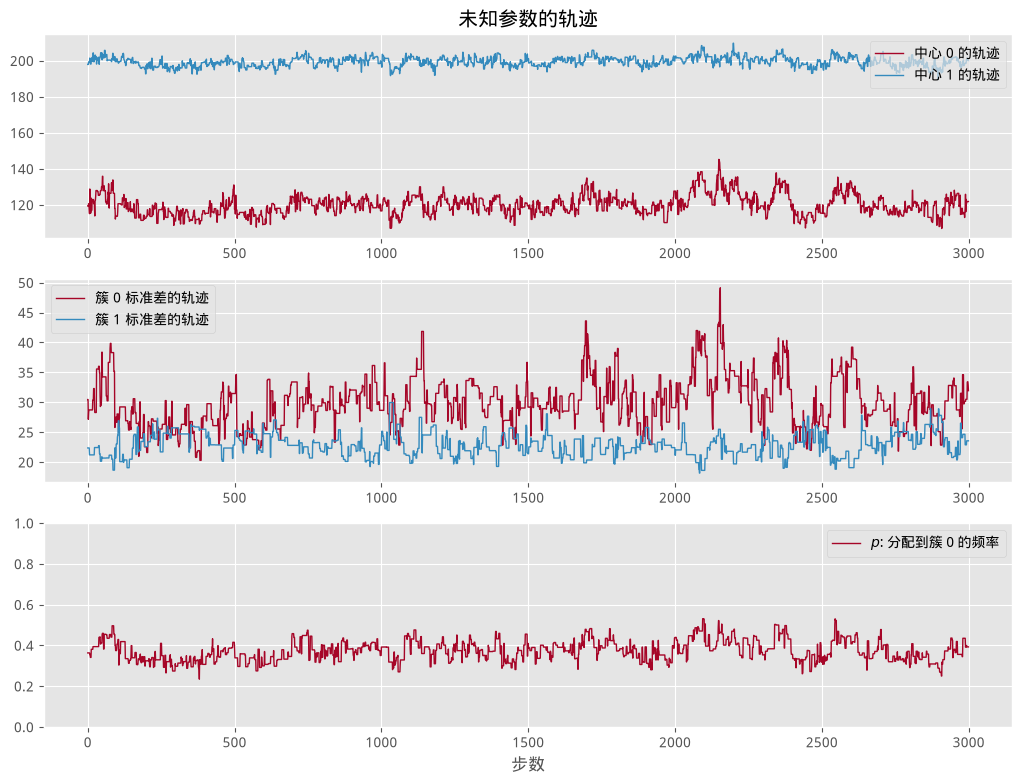

In [9]:

figsize(12.5, 9)
plt.subplot(311)
lw = 1
center_trace = trace1["centers"]

# 为了后面画图好看
colors = ["#348ABD", "#A60628"] if center_trace[-1, 0] > center_trace[-1, 1] \
    else ["#A60628", "#348ABD"]

plt.plot(center_trace[:, 0], label="中心 0 的轨迹", c=colors[0], lw=lw)
plt.plot(center_trace[:, 1], label="中心 1 的轨迹", c=colors[1], lw=lw)
plt.title("未知参数的轨迹")
leg = plt.legend(loc="upper right")
leg.get_frame().set_alpha(0.7)

plt.subplot(312)
std_trace = trace1["sds"]
plt.plot(std_trace[:, 0], label="簇 0 标准差的轨迹",
         c=colors[0], lw=lw)
plt.plot(std_trace[:, 1], label="簇 1 标准差的轨迹",
         c=colors[1], lw=lw)
plt.legend(loc="upper left")

plt.subplot(313)
p_trace = trace1["p"]
plt.plot(p_trace, label="$p$: 分配到簇 0 的频率",
         color=colors[0], lw=lw)
plt.xlabel("步数")
plt.ylim(0, 1)
plt.legend();



强大的 Arviz InferenceData 及其配套 API,能给我们提供更舒适的查看方式。


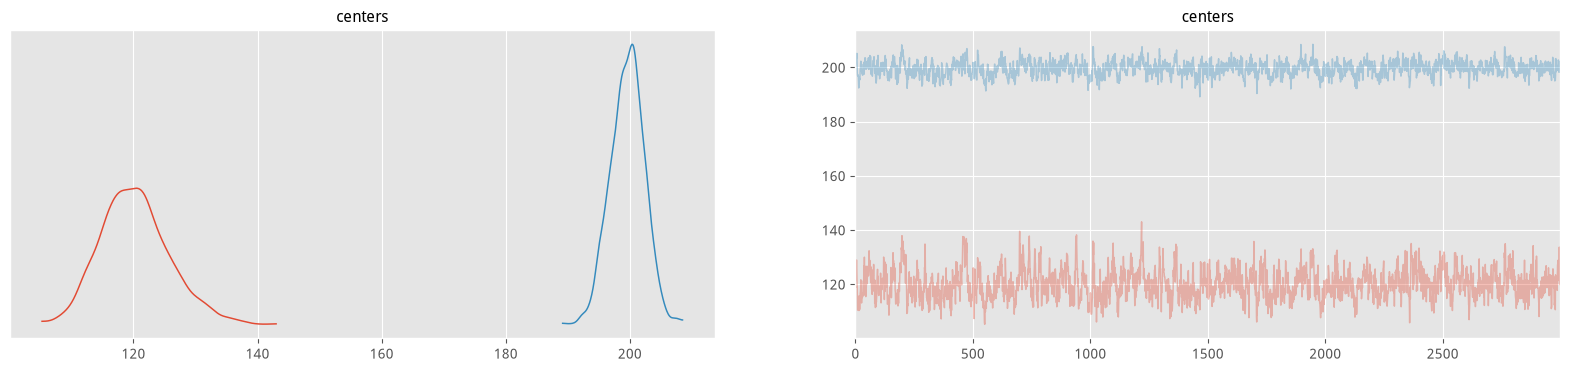

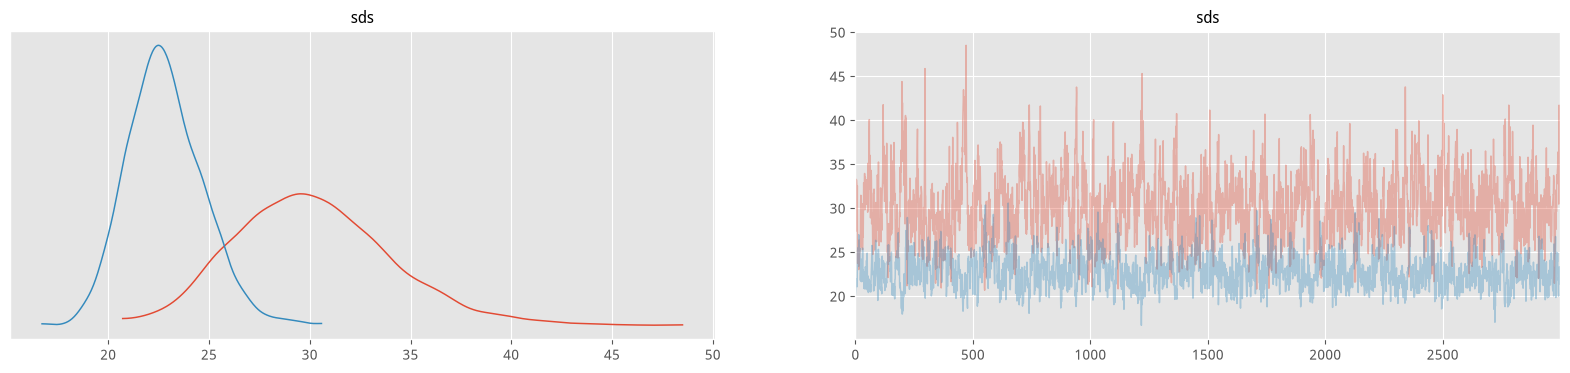

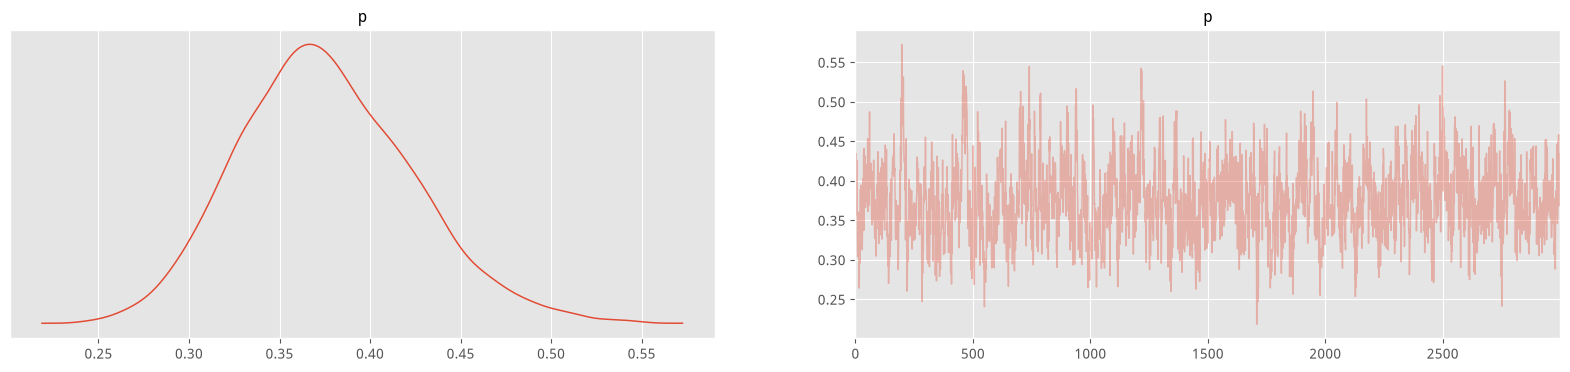

In [10]:

az.plot_trace(trace2.posterior.centers, figsize=(20, 4))
az.plot_trace(trace2.posterior.sds, figsize=(20, 4))
az.plot_trace(trace2.posterior.p, figsize=(20, 4))
plt.show()



注意以下几个特征:

1. 这些轨迹并没有收敛到*单独一个点*,而是收敛到了一批可能取值构成的*分布*。这就是 MCMC 算法里所说的*收敛*(convergence)。
2. 用最开始的那几千个点做推断是个坏主意,因为它们和我们最终关心的分布毫无关系。因此,在把样本用于推断之前,最好先把这些样本丢弃。我们把这段"尚未收敛"的时期称为*预热期*(burn-in period)。可以用参数 `tune` 和 `discard_tuned_samples`(默认为 True)来处理这段预热期。
3. 这些轨迹看起来像是在空间中随机"游走",也就是说,路径和之前的位置存在相关性。这既是好事也是坏事:当前位置和之前位置之间总会存在一定的相关性,但如果相关性太强,就说明我们对空间的探索不够充分。本章后面的"诊断"一节会详细讨论这一点。

请注意,"从已有的 MultiTrace 对象继续采样"这个功能已经不再支持了,所以我们需要重新开始一次采样过程,并把抽样数改成 6000(即在原来 3000 的基础上再翻一倍;现代 PyMC 小贴士:原书这里用的是从 25000 翻倍到 50000,在没有 C 编译器、只能用 NUMBA 后端的环境下这个规模会非常耗时,这里按比例调小了)。

下面我们再多采样 3000 次,并把过程可视化出来:


In [11]:

with model:
    trace3 = pm.sample(6000, step=[step3], tune=1000, chains=1)


Sequential sampling (1 chains in 1 job)


CompoundStep


>CategoricalGibbsMetropolis: [assignment]


>NUTS: [p, sds, centers]


Output()

Sampling 1 chain for 1_000 tune and 6_000 draw iterations (1_000 + 6_000 draws total) took 369 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


/tmp/ipykernel_3428962/1183555396.py:2: FutureWarning: extract_dataset has been deprecated, please use extract
  sample_data = az.extract_dataset(trace3)


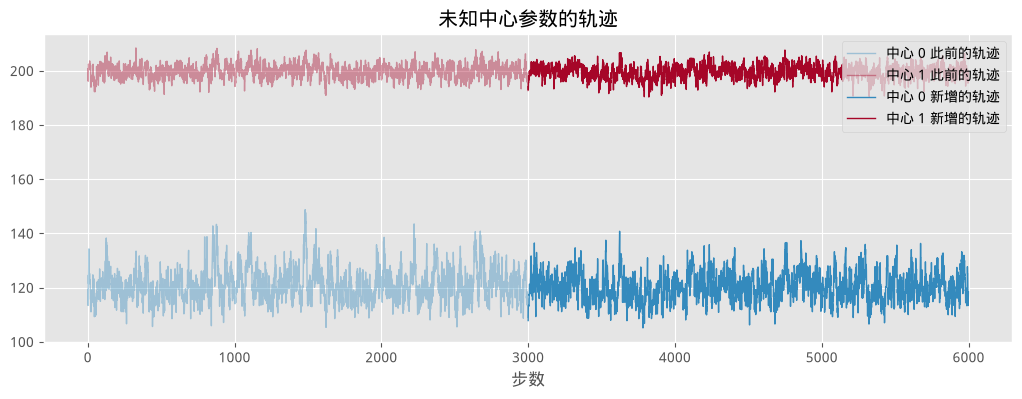

In [12]:

figsize(12.5, 4)
sample_data = az.extract_dataset(trace3)
center_trace_after_25000 = sample_data.centers.data[:, 3000:]
center_trace_before25000 = sample_data.centers.data[:, :3000]

x = np.arange(3000)
plt.plot(x, center_trace_before25000[0, :], label="中心 0 此前的轨迹",
         lw=lw, alpha=0.4, c=colors[1])
plt.plot(x, center_trace_before25000[1, :], label="中心 1 此前的轨迹",
         lw=lw, alpha=0.4, c=colors[0])

x = np.arange(3000, 6000)
plt.plot(x, center_trace_after_25000[0, :], label="中心 0 新增的轨迹", lw=lw, c="#348ABD")
plt.plot(x, center_trace_after_25000[1, :], label="中心 1 新增的轨迹", lw=lw, c="#A60628")

plt.title("未知中心参数的轨迹")
leg = plt.legend(loc="upper right")
leg.get_frame().set_alpha(0.8)
plt.xlabel("步数");


[]

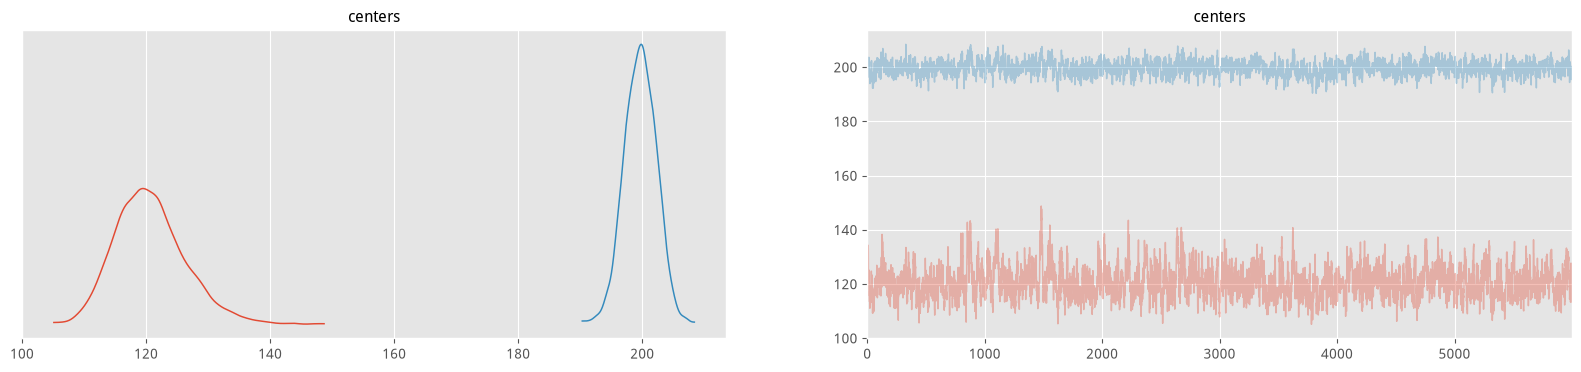

In [13]:

az.plot_trace(trace3.posterior.centers, figsize=(20, 4))
plt.plot()



#### 考察聚类结果

我们并没有忘记自己的主要目标:识别出各个簇。我们已经求出了未知量的后验分布。下面画出中心和标准差变量的后验分布:


/tmp/ipykernel_3428962/593834359.py:2: FutureWarning: extract_dataset has been deprecated, please use extract
  sample_data = az.extract_dataset(trace3)


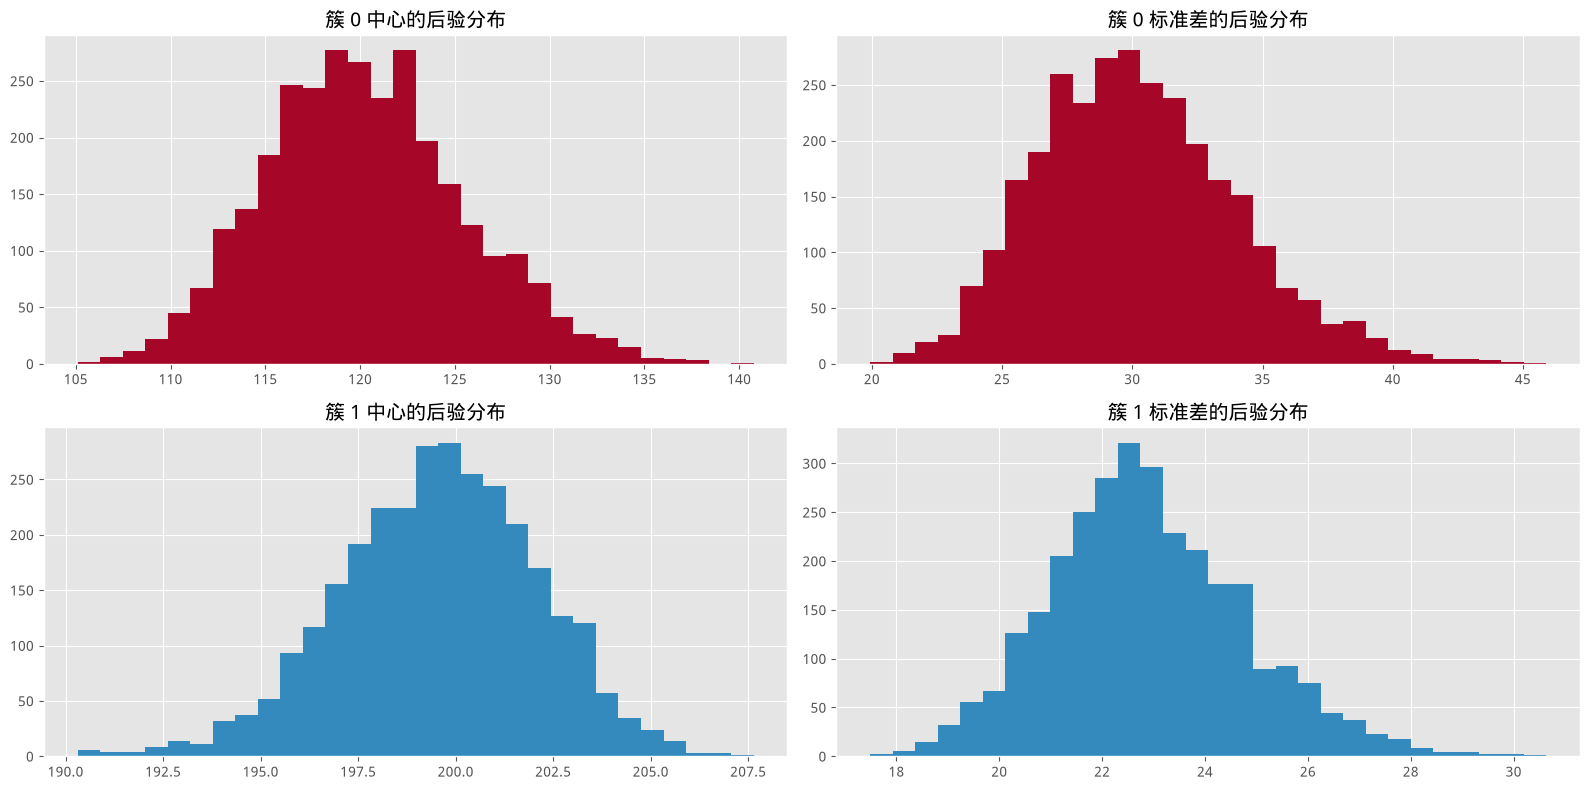

In [14]:

figsize(16.0, 8)
sample_data = az.extract_dataset(trace3)
std_trace_after25000 = sample_data.sds.data[:, 3000:]
std_trace_before25000 = sample_data.sds.data[:, :3000]

_i = [1, 2, 3, 4]
for i in range(2):
    plt.subplot(2, 2, _i[2 * i])
    plt.title("簇 %d 中心的后验分布" % i)
    plt.hist(center_trace_after_25000[i, :], color=colors[i], bins=30,
             histtype="stepfilled")

    plt.subplot(2, 2, _i[2 * i + 1])
    plt.title("簇 %d 标准差的后验分布" % i)
    plt.hist(std_trace_after25000[i, :], color=colors[i], bins=30,
             histtype="stepfilled")
    # plt.autoscale(tight=True)

plt.tight_layout()


[]

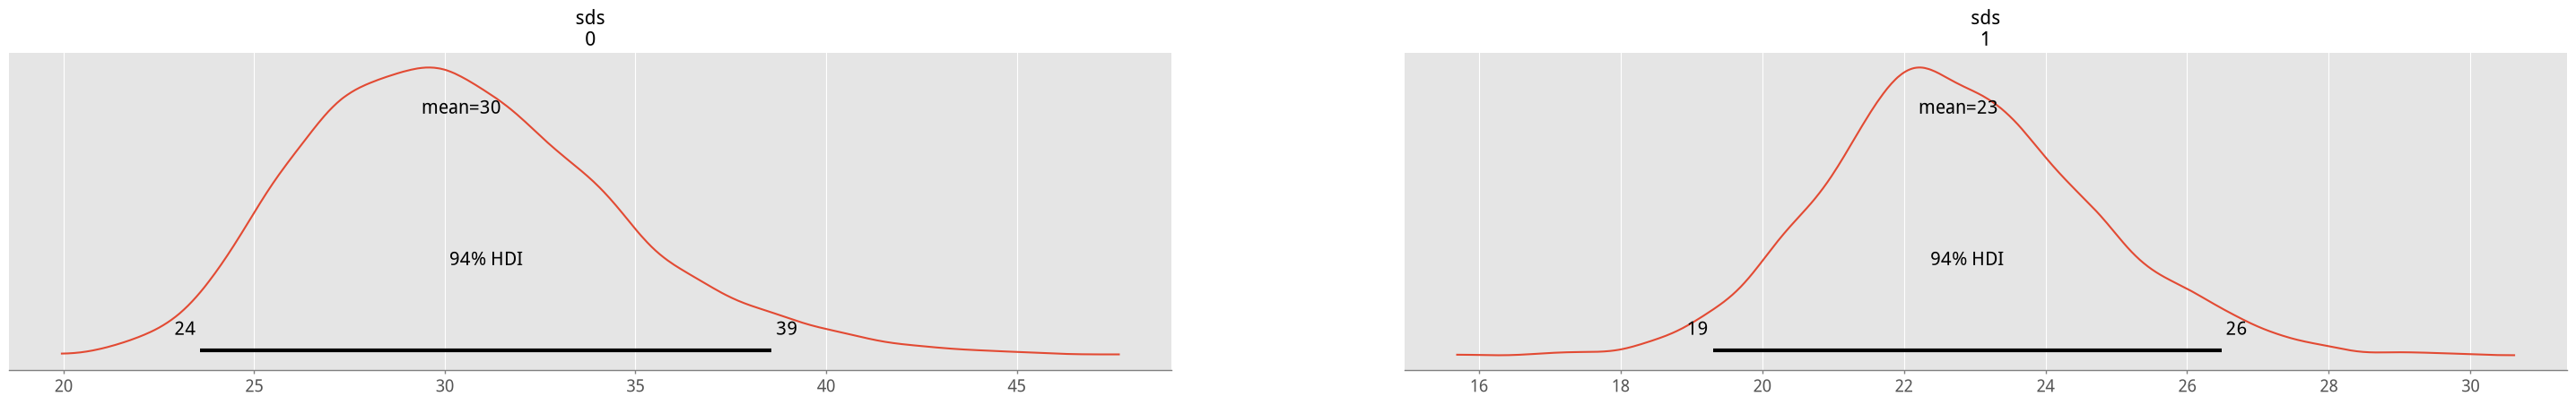

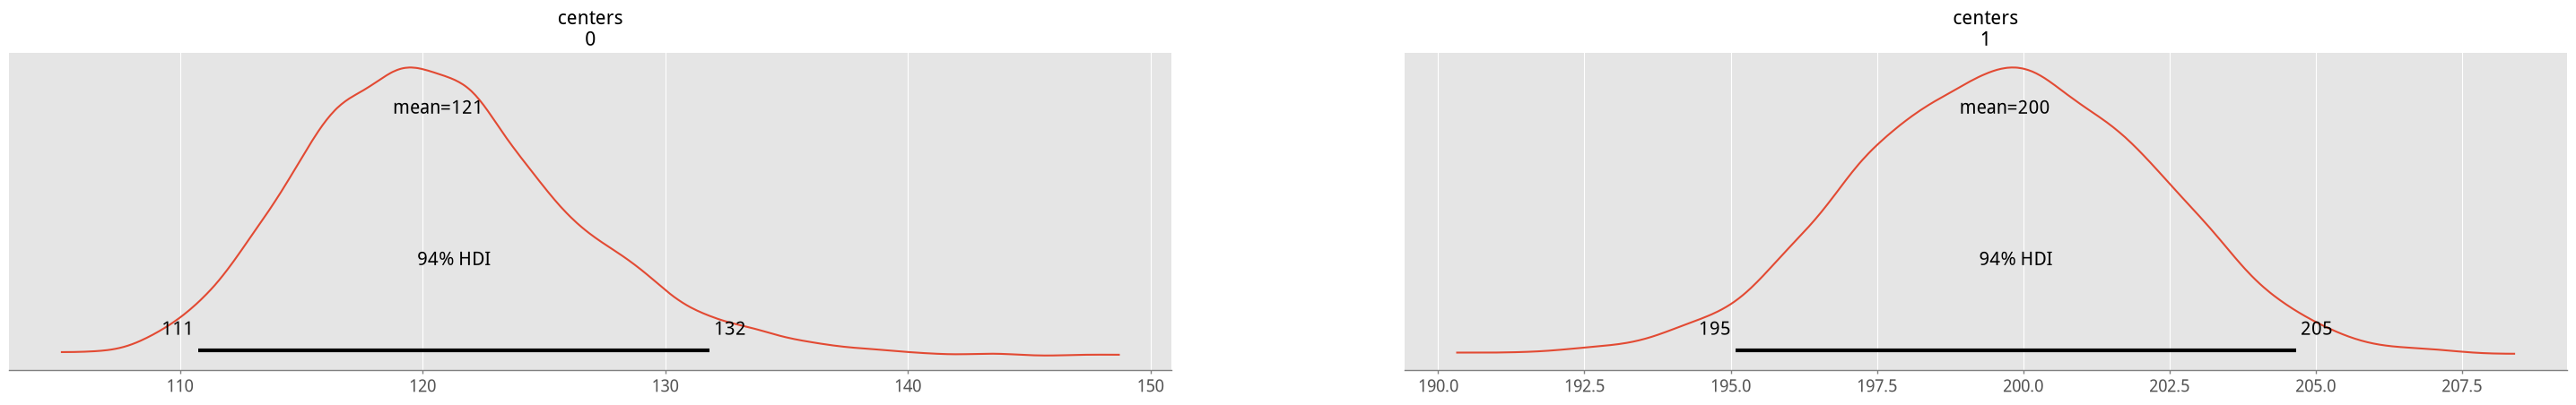

In [15]:

az.plot_posterior(trace3, var_names=["sds"], figsize=figsize(16.0, 4))
az.plot_posterior(trace3, var_names=["centers"], figsize=figsize(16.0, 4))
plt.plot()



MCMC 算法给出的结果表明,两个簇最可能的中心分别在 120 和 200 附近。标准差也可以做类似的推断。

我们同时也得到了每个数据点标签的后验分布,保存在 `trace["assignment"]` 里。下面是它的可视化展示。纵轴代表每个数据点后验标签的一个子样本,横轴是排好序的数据点取值。红色方块代表被分配到簇 1,蓝色方块代表被分配到簇 0。


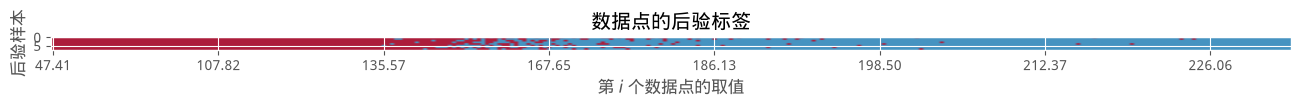

In [16]:

import matplotlib as mpl
figsize(16, 4)
plt.cmap = mpl.colors.ListedColormap(colors)
plt.imshow(sample_data.assignment.data.T[::800, np.argsort(data)],
           cmap=plt.cmap, aspect=.4, alpha=.9)
plt.xticks(np.arange(0, data.shape[0], 40),
           ["%.2f" % s for s in np.sort(data)[::40]])
plt.ylabel("后验样本")
plt.xlabel("第 $i$ 个数据点的取值")
plt.title("数据点的后验标签");



从上图可以看出,不确定性最高的区域大概在 150 到 170 之间。不过上图的呈现方式其实有一点误导性,因为横轴并不是真正的等间隔刻度(它展示的是排好序之后第 $i$ 个数据点的取值)。下面是一张更清晰的图,我们估计了每个数据点被分配到标签 0 和标签 1 的*频率*。


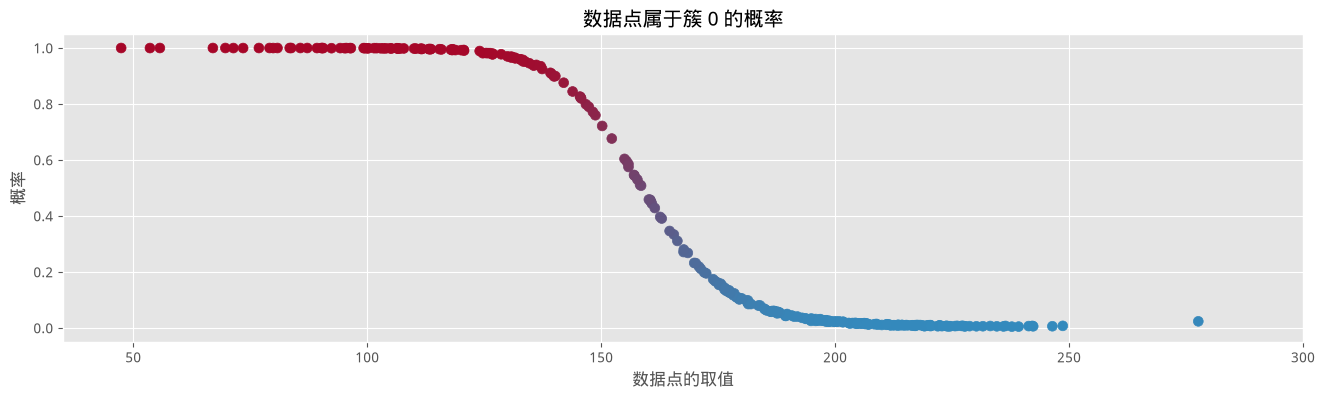

In [17]:

cmap = mpl.colors.LinearSegmentedColormap.from_list("BMH", colors)
assign_trace = sample_data.assignment.data.T
plt.scatter(data, 1 - assign_trace.mean(axis=0), cmap=cmap,
            c=assign_trace.mean(axis=0), s=50)
plt.ylim(-0.05, 1.05)
plt.xlim(35, 300)
plt.title("数据点属于簇 0 的概率")
plt.ylabel("概率")
plt.xlabel("数据点的取值");



尽管我们用正态分布为两个簇建模,但我们并没有得到*一个*"最"拟合数据的正态分布(不管"最"的定义是什么),而是得到了正态分布参数的一整个分布。那要怎么从中挑出*一组*均值和方差,来确定一个"差不多最优拟合"的高斯分布呢?

一种简单粗暴、但理论性质不错(我们会在第五章看到)的方法,是使用后验分布的*均值*。下面我们用后验分布的均值作为选定的参数,把正态密度函数叠加到观测数据上:


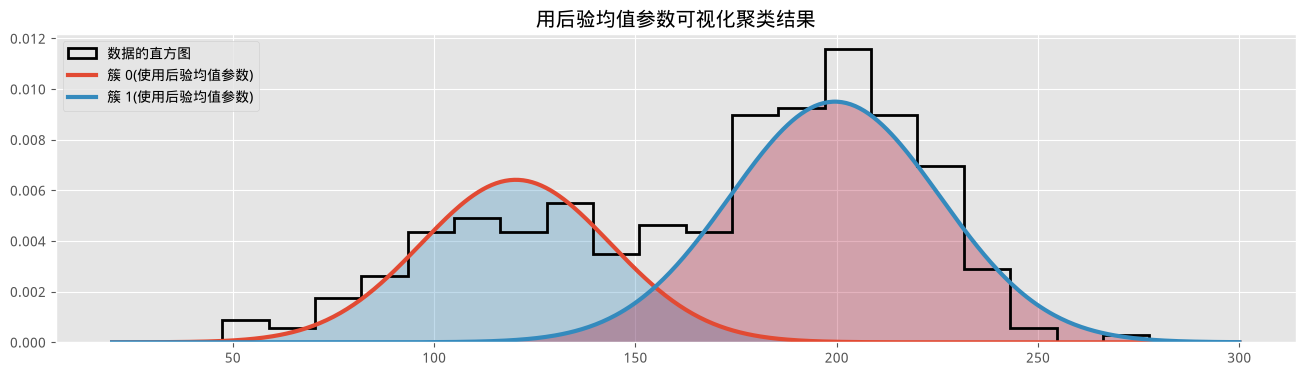

In [18]:

norm = stats.norm
x = np.linspace(20, 300, 500)
posterior_center_means = center_trace_after_25000.T.mean(axis=0)
posterior_std_means = std_trace_after25000.mean(axis=0)
posterior_p_mean = sample_data.p.data.mean()

plt.hist(data, bins=20, histtype="step", density=True, color="k",
         lw=2, label="数据的直方图")
y = posterior_p_mean * norm.pdf(x, loc=posterior_center_means[0],
                                 scale=posterior_std_means[0])
plt.plot(x, y, label="簇 0(使用后验均值参数)", lw=3)
plt.fill_between(x, y, color=colors[1], alpha=0.3)

y = (1 - posterior_p_mean) * norm.pdf(x, loc=posterior_center_means[1],
                                       scale=posterior_std_means[1])
plt.plot(x, y, label="簇 1(使用后验均值参数)", lw=3)
plt.fill_between(x, y, color=colors[0], alpha=0.3)

plt.legend(loc="upper left")
plt.title("用后验均值参数可视化聚类结果");



### 重要提示: 不要混用不同的后验样本

在上面的例子里,一种可能(虽然可能性较低)的情形是:簇 0 的标准差非常大,而簇 1 的标准差很小。这依然能够满足证据,只是没有我们原来的推断那么符合而已。反过来,*两个*分布的标准差都很小几乎是不可能的,因为数据完全不支持这个假设。所以这两个标准差之间是*相互依赖*的:如果一个很小,另一个就必定很大。事实上,*所有*未知量之间都以类似的方式相互关联。举例来说,如果某个标准差很大,均值可实现的取值范围就会更宽;反之,较小的标准差会把均值限制在一个较小的区域内。

在 MCMC 过程中,我们得到的是一系列表示未知后验样本的向量。不同向量里的元素不能混在一起使用,否则就会破坏上面这套逻辑:也许某一个样本里簇 1 的标准差恰好很小,那么这个样本里的其他所有变量也都会相应地调整、以适应这一点。不过要避免这个问题也很简单,只要保证正确地对轨迹做索引就行了。

再举一个小例子来说明这一点。假设两个变量 $x$ 和 $y$ 满足 $x+y=10$。我们把 $x$ 建模为均值为 4 的正态随机变量,并探索 500 个样本。


Sequential sampling (1 chains in 1 job)


Metropolis: [x]


Output()

Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 1 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


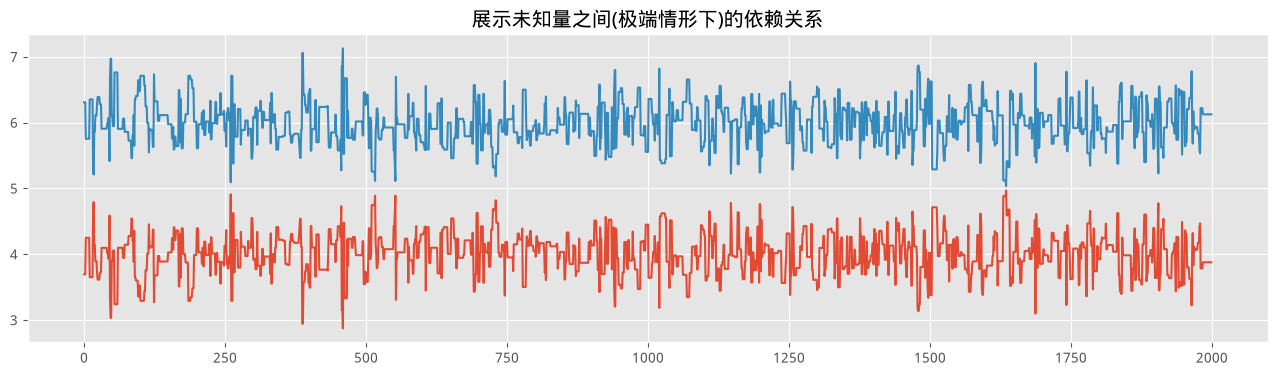

In [19]:

import pymc as pm

with pm.Model() as model:
    x = pm.Normal("x", mu=4, tau=10)
    y = pm.Deterministic("y", 10 - x)

    # 现代 PyMC 小贴士: 原书这里把 step 对象作为第二个位置参数传入,
    # 但现代 pm.sample() 的签名里, draws 之后的所有参数都变成了
    # "仅限关键字参数"(keyword-only), 必须显式写成 step=...。
    trace_2 = pm.sample(2000, step=pm.Metropolis(), chains=1)

plt.plot(trace_2.posterior.x.T)
plt.plot(trace_2.posterior.y.T)
plt.title("展示未知量之间(极端情形下)的依赖关系");



可以看到,这两个变量并非毫无关联,除非 $i=j$,否则把 $x$ 的第 $i$ 个样本和 $y$ 的第 $j$ 个样本加在一起是错误的。



#### 回到聚类问题:预测

上面的聚类方法可以推广到 $k$ 个簇。选择 $k=2$ 是为了能更好地可视化 MCMC 的过程,并观察一些非常有意思的图。

那预测呢?假设我们观测到一个新数据点,比如 $x=175$,我们想给它打上一个簇标签。如果只是简单地把它分配给*最近*的簇中心,那就未免太草率了,因为这忽略了各个簇的标准差——而我们从上面的图已经看到,标准差这个因素非常重要。更严谨地说:我们真正关心的是把 $x=175$ 分配给簇 1 的*概率*(因为我们没法确定标签一定是什么)。记 $x$ 的分配结果为 $L_x$,取值为 0 或 1,我们关心的是 $P(L_x = 1 \;|\; x = 175)$。

一种朴素的计算方法,是把新数据点加进去,重新跑一遍上面的 MCMC。这种方法的缺点是,每来一个新的数据点都要重新推断一次,速度会很慢。另一种方法则*不那么精确*,但快得多。

我们会用贝叶斯定理来做这件事。回忆一下,贝叶斯定理长这样:

$$ P( A | X ) = \frac{ P( X  | A )P(A) }{P(X) }$$

在我们的情形里,$A$ 代表 $L_x=1$,$X$ 是我们已经掌握的证据:我们观测到 $x=175$。对后验分布中某一组具体的参数取值 $(\mu_0, \sigma_0, \mu_1, \sigma_1, p)$,我们关心的问题是:"$x$ 属于簇 1 的概率,是否*大于*属于簇 0 的概率?"——这里的概率取决于选定的参数。

\begin{align}
& P(L_x = 1| x = 175 ) \gt P(L_x = 0| x = 175 ) \\\\[5pt]
& \frac{ P( x=175  | L_x = 1  )P( L_x = 1 ) }{P(x = 175) } \gt \frac{ P( x=175  | L_x = 0  )P( L_x = 0 )}{P(x = 175) }
\end{align}

由于两边的分母相等,可以直接约掉(而且这样正好,因为计算 $P(x=175)$ 这个量本身就很麻烦)。

$$  P( x=175  | L_x = 1  )P( L_x = 1 ) \gt  P( x=175  | L_x = 0  )P( L_x = 0 ) $$


In [20]:

norm_pdf = stats.norm.pdf
p_trace = trace3.posterior.p.data[:, 3000:]
prev_p_trace = trace3.posterior.p.data[:, :3000]
# 从 trace3 更新 center_trace 和 std_trace
center_trace = trace3.posterior.centers.data[:, 3000:, :]
std_trace = trace3.posterior.sds.data[:, 3000:, :]
x = 175

v = p_trace[0, :] * norm_pdf(x, loc=center_trace[:, :, 0], scale=std_trace[:, :, 0]) > \
    (1 - p_trace)[0, :] * norm_pdf(x, loc=center_trace[:, :, 1], scale=std_trace[:, :, 1])

print("属于簇 1 的概率:", v.mean())


属于簇 1 的概率: 0.0006666666666666666



比起简单粗暴地给出一个标签,能给出一个概率是非常有用的。相比朴素的:

    L = 1 if prob > 0.5 else 0

我们可以借助*损失函数*来优化我们的猜测,整个第五章都会专门讨论这个话题。

### 用 `MAP` 改善收敛性

如果你自己跑过上面的例子,可能会注意到我们的结果并不总是一致的:也许你得到的簇划分更分散,也许更集中。问题在于,我们的轨迹其实是 MCMC 算法*起始值*的一个函数。

可以从数学上证明,只要让 MCMC 运行足够长的时间(执行足够多的步数),算法*应该会忘记自己的初始位置*。事实上,这正是"MCMC 已收敛"这句话的含义(不过实践中我们永远无法达到完全的收敛)。所以,如果我们观察到不同的后验分析结果,很可能是因为 MCMC 还没有完全收敛,我们不应该急着使用它的样本(应该用更长的预热期)。

事实上,糟糕的起始值可能会彻底阻止收敛,或者显著拖慢收敛速度。理想情况下,我们希望链一开始就落在地貌的*峰顶*,因为那正是后验分布真正存在的地方。因此,如果从"峰顶"开始,我们就可以避免漫长的预热期和错误的推断。通常,我们把这个"峰顶"称为*最大后验*(maximum a posterior),或者更简单地,叫做 *MAP*。

当然,我们并不知道 MAP 究竟在哪里。PyMC 提供了一个函数,可以近似地(即使不能精确地)找到 MAP 的位置。在 PyMC 的主命名空间下有一个 `find_MAP` 函数。如果你在 `Model()` 的上下文中调用这个函数,它会计算出 MAP,你可以把它作为 `start` 参数传给 `pm.sample()`。

    start = pm.find_MAP()
    trace = pm.sample(2000, step=pm.Metropolis, start=start)

`find_MAP()` 函数很灵活,允许用户选择使用哪种优化算法(毕竟这本质上是一个优化问题:我们要找到能让地貌取值最大化的那组参数),因为不同的优化算法效果并不都一样。这个函数调用默认使用的优化算法是 Broyden-Fletcher-Goldfarb-Shanno([BFGS](https://en.wikipedia.org/wiki/Broyden-Fletcher-Goldfarb-Shanno_algorithm))算法,用来寻找对数后验的最大值。你也可以选用 `scipy.optimize` 模块里的其他优化算法。例如,你可以调用 `find_MAP(fmin=scipy.optimize.fmin_powell)`,使用 Powell 方法——这是 PyMC 博主 [Abraham Flaxman](http://healthyalgorithms.com/) [1] 最喜欢的方法。默认算法通常已经够用了,但如果收敛缓慢或者无法保证收敛,不妨试试 Powell 方法或其他可用的算法。

MAP 本身也可以作为推断问题的一个解,因为从数学上讲,它就是未知量*最可能*的取值。但正如本章前面提到的,这个位置忽略了不确定性,也不会返回一个分布。

#### 再说说预热期

即便我们在采样前用了 `find_MAP()`,提前决定一个预热期仍然是个好主意,以策万全。在新版 PyMC(v4)中,我们不能再像 PyMC2 那样,在 `sample()` 函数里用一个 `burn` 参数来自动丢弃预热样本了,取而代之的是新的 `tune` 和 `discard_tuned_samples` 参数。`tune` 指定要用多少次迭代来做"调参"(默认是 1000),采样器会在调参阶段调整步长、缩放系数等设置。调参阶段抽取的样本,是在 `draws` 参数指定的样本数之外*额外*抽取的,除非把 `discard_tuned_samples` 设为 `False`,否则这些样本会被丢弃。旧版的 `start` 参数也改名成了 `initvals`,而且现在功能更强大。新代码大致长这样:

    with pm.Model() as model:
        start = pm.find_MAP()

        step = pm.Metropolis()
        trace = pm.sample(100000, step=step, initvals=start, tune=50000)



## 诊断收敛性

### 自相关

自相关(autocorrelation)衡量的是一串数字与自身之间有多相关。1.0 表示完美的正相关,0 表示没有自相关,-1 表示完美的负相关。如果你熟悉标准的*相关性*概念,那么自相关其实就是:一个序列 $x_t$ 在时刻 $t$ 的取值,与它自己在时刻 $t-k$ 的取值之间有多相关:

$$R(k) = Corr( x_t, x_{t-k} ) $$

举例来说,考虑下面两个序列:

$$x_t \sim \text{Normal}(0,1), \;\; x_0 = 0$$
$$y_t \sim \text{Normal}(y_{t-1}, 1 ), \;\; y_0 = 0$$

它们的路径示例长这样:


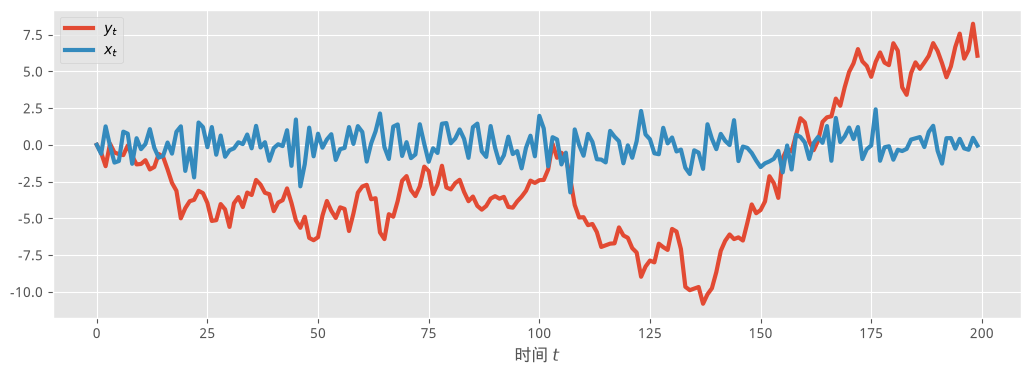

In [21]:

figsize(12.5, 4)

x_t = np.random.normal(0, 1, 200)
x_t[0] = 0
y_t = np.zeros(200)
for i in range(1, 200):
    y_t[i] = np.random.normal(y_t[i - 1], 1)

plt.plot(y_t, label="$y_t$", lw=3)
plt.plot(x_t, label="$x_t$", lw=3)
plt.xlabel("时间 $t$")
plt.legend();



理解自相关的一种方式是:"如果我知道序列在时刻 $s$ 的位置,这能不能帮我推测出时刻 $t$ 的位置?"对序列 $x_t$ 来说,答案是不能。按照构造方式,$x_t$ 本身就是随机变量。如果我告诉你 $x_2=0.5$,你能更好地猜出 $x_3$ 吗?不能。

反过来,$y_t$ 是自相关的。按照构造方式,如果我知道 $y_2=10$,我就可以很有把握地说 $y_3$ 不会离 10 太远。类似地,我甚至可以对 $y_4$ 做出一个(把握没那么大的)猜测:它大概不会靠近 0 或 20,但取值 5 也不算太离谱。对 $y_5$ 我也能做类似的论证,只是把握又更低了一些。把这个逻辑推到极致,我们必须承认:随着时间点之间的间隔 $k$(也叫"滞后",lag)增大,自相关会逐渐减弱。我们可以把它可视化出来:


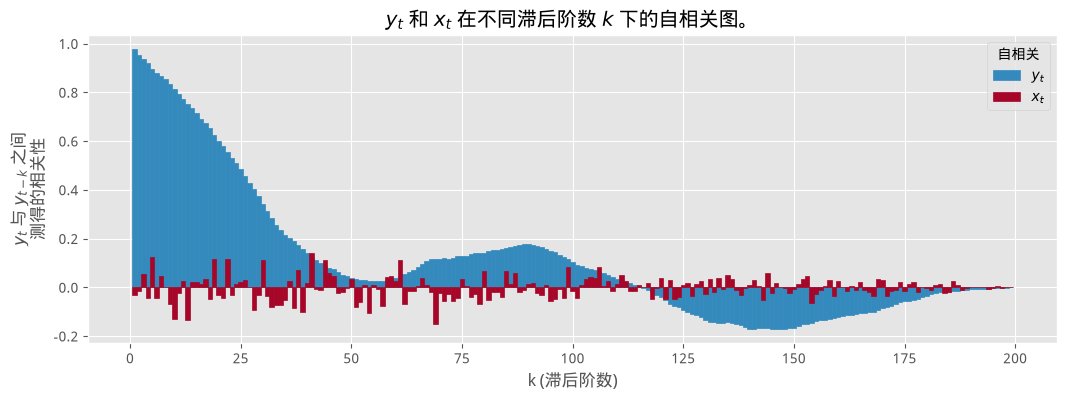

In [22]:

def autocorr(x):
    # 来自 http://tinyurl.com/afz57c4
    result = np.correlate(x, x, mode='full')
    result = result / np.max(result)
    return result[result.size // 2:]

colors = ["#348ABD", "#A60628", "#7A68A6"]

x = np.arange(1, 200)
plt.bar(x, autocorr(y_t)[1:], width=1, label="$y_t$",
        edgecolor=colors[0], color=colors[0])
plt.bar(x, autocorr(x_t)[1:], width=1, label="$x_t$",
        color=colors[1], edgecolor=colors[1])

plt.legend(title="自相关")
plt.ylabel("$y_t$ 与 $y_{t-k}$ 之间\n测得的相关性")
plt.xlabel("k (滞后阶数)")
plt.title("$y_t$ 和 $x_t$ 在不同滞后阶数 $k$ 下的自相关图。");



可以看到,随着 $k$ 增大,$y_t$ 的自相关从一个很高的点逐渐下降。再对比 $x_t$ 的自相关,它看起来就像噪声(事实也确实如此),因此可以断定这个序列不存在自相关。

#### 这和 MCMC 的收敛性有什么关系?

由于 MCMC 算法本身的性质,我们得到的样本必然会表现出自相关(因为算法的每一步都是"从当前位置,移动到附近的一个位置")。

一条没能充分探索空间的链,会表现出非常高的自相关。直观地看,如果轨迹看起来像一条河流一样蜿蜒曲折、迟迟不"安定"下来,这条链就存在很高的自相关。

不过这并不意味着一条已经收敛的 MCMC 链就一定自相关很低。因此,低自相关并不是收敛的*必要*条件,但却是一个*充分*条件。PyMC 有一个相当新的绘图库,叫做 Arviz,是一个专门用于"贝叶斯模型探索性分析"的通用库,我们在前面已经见过一些 arviz 的绘图示例了。



### 稀疏化(Thinning)

如果后验样本之间存在高度自相关,还会带来另一个问题。很多后续处理算法都要求样本彼此*独立*。这个问题可以通过"每隔 $n$ 个样本才返回给用户一个"来解决(或者至少能缓解),从而去除一部分自相关。下面我们对 $y_t$ 在不同稀疏化程度下画出自相关图:


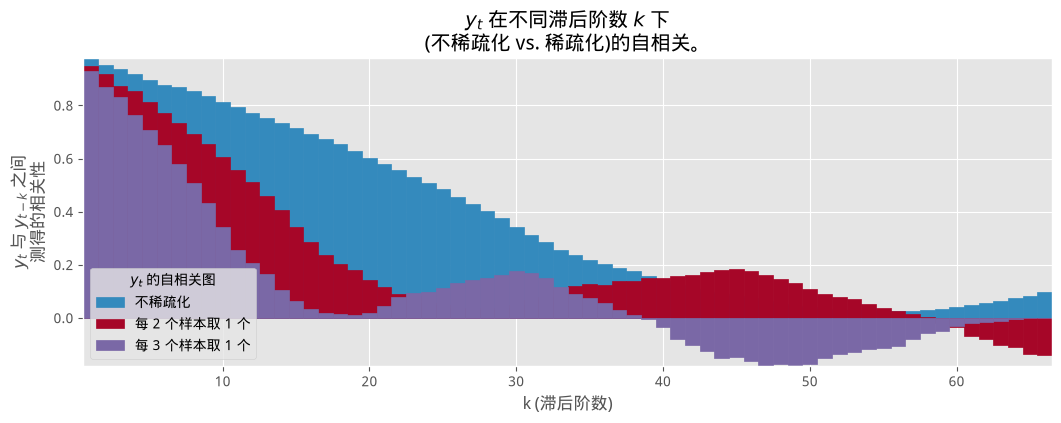

In [23]:

max_x = 200 // 3 + 1
x = np.arange(1, max_x)

plt.bar(x, autocorr(y_t)[1:max_x], edgecolor=colors[0],
        label="不稀疏化", color=colors[0], width=1)
plt.bar(x, autocorr(y_t[::2])[1:max_x], edgecolor=colors[1],
        label="每 2 个样本取 1 个", color=colors[1], width=1)
plt.bar(x, autocorr(y_t[::3])[1:max_x], width=1, edgecolor=colors[2],
        label="每 3 个样本取 1 个", color=colors[2])

plt.autoscale(tight=True)
plt.legend(title="$y_t$ 的自相关图", loc="lower left")
plt.ylabel("$y_t$ 与 $y_{t-k}$ 之间\n测得的相关性")
plt.xlabel("k (滞后阶数)")
plt.title("$y_t$ 在不同滞后阶数 $k$ 下\n(不稀疏化 vs. 稀疏化)的自相关。");



稀疏化程度越高,自相关下降得越快。不过这里存在一个权衡:稀疏化程度越高,想要得到同样数量的返回样本,就需要更多的 MCMC 迭代次数。举例来说,不稀疏化的 10000 个样本,如果稀疏化系数是 10,就需要采样 100000 次(尽管后者的自相关更低)。

那多大的稀疏化程度才算合适呢?不管稀疏化到什么程度,返回的样本总会存在一定的自相关。只要自相关趋于零,通常就没什么问题。一般来说,稀疏化系数超过 10 就没什么必要了。



### `Arviz`

每次做 MCMC 都要手动画直方图、自相关图和轨迹图,未免有点傻。PyMC 的作者们正是为此内置了一个可视化工具。

`arviz` 库包含了大量你可能会用到的绘图函数。对于其中的每一个绘图函数,你只需要传入采样得到的 `trace`,以及一个你感兴趣的变量列表 `var_names`。这个模块可以为你提供自相关图、每个变量的后验分布图和轨迹图等等。

下面我们用这个工具画出各个簇中心的图。


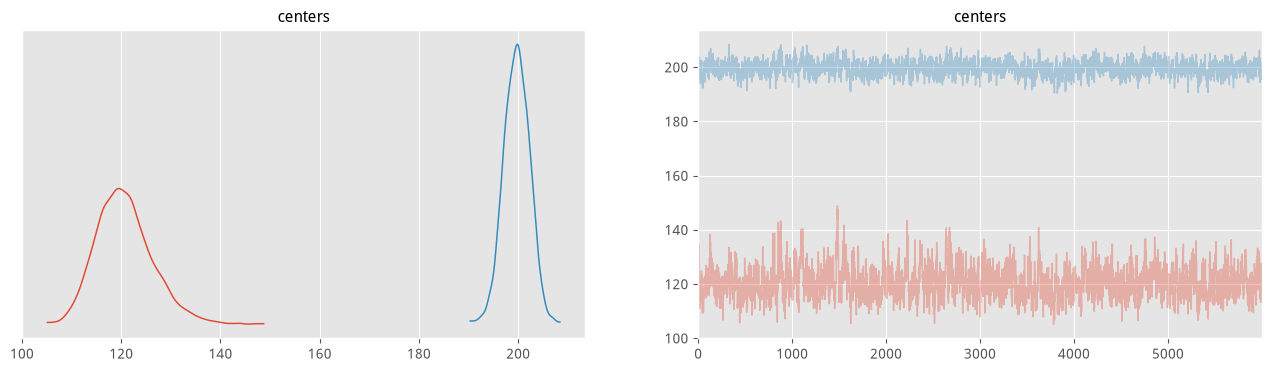

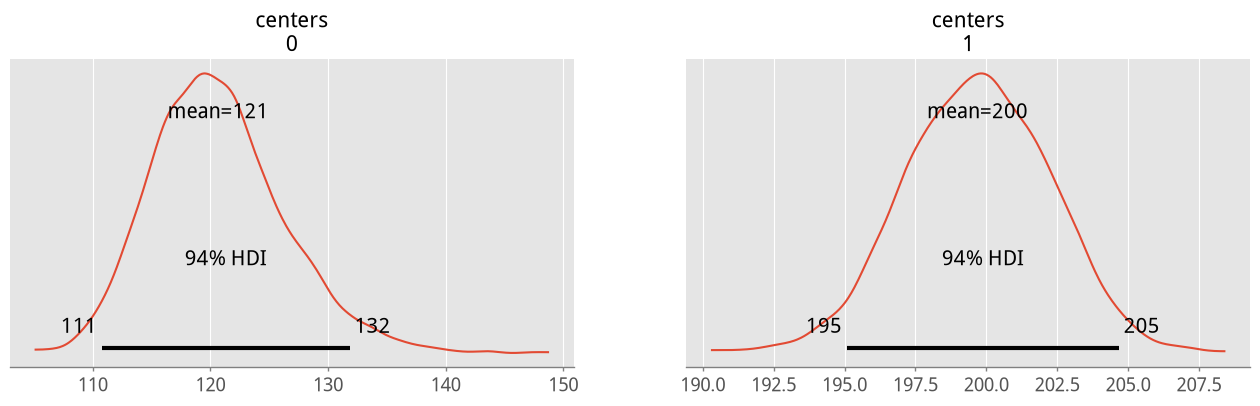

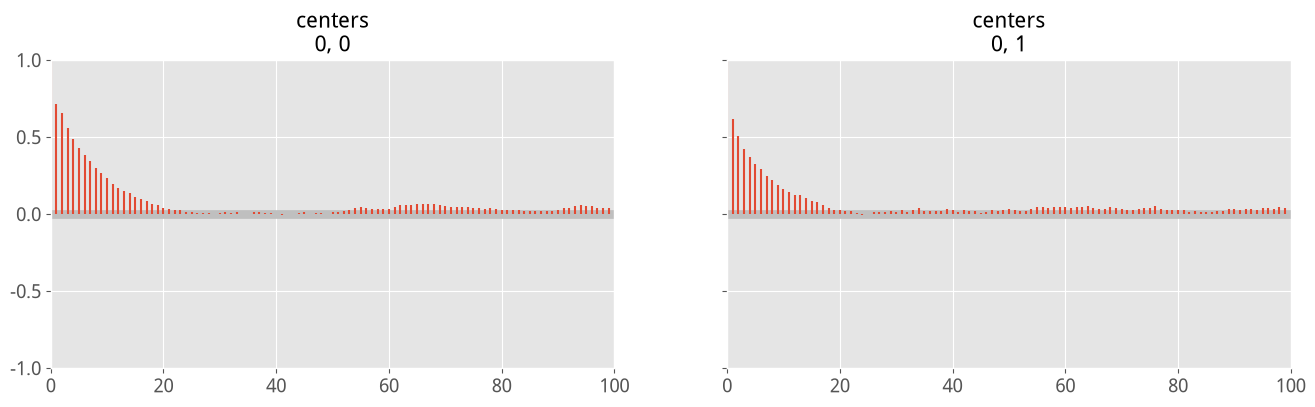

In [24]:

az.plot_trace(data=trace3, var_names=["centers"], figsize=(16, 4))
az.plot_posterior(data=trace3, var_names=["centers"], figsize=(16, 4))
# az.plot_posterior(data=trace3["centers"][:,1])
az.plot_autocorr(data=trace3, var_names=["centers"], figsize=(16, 4));



第一个绘图函数,给出了 `centers` 变量里每个未知量的后验密度,以及各自的 `trace`(轨迹)图。`trace` 图对于检查那种可能由未收敛导致的"蜿蜒"现象很有用。密度图则能让我们大致了解每个未知量分布的形状,不过最好还是分别单独查看每一个。



第二组绘图函数,给我们提供了带有一些附加信息的样本直方图。图中间的文字标注给出了后验均值,这是对后验分布很好的一个概括统计量。图上用横向黑线标出的区间,代表*95% 可信区间*,有时也叫*最高后验密度区间*(highest posterior density interval),注意不要把它和*95% 置信区间*混淆。我们不会深入讨论后者,但前者可以理解为"该参数有 95% 的(后验)概率落在这个区间内"。在向他人汇报结果时,说明这个区间非常重要。我们学习贝叶斯方法的目的之一,正是要对未知量的不确定性有一个清晰的认识。把后验均值和 95% 可信区间结合起来,就能给出一个可靠的区间,既能传达未知量最可能所在的位置(由均值给出),*又*能传达不确定性的大小(由区间宽度体现)。



最后几张标题为 `center_0` 和 `center_1` 的图,是生成出来的自相关图,和上面展示过的类似。



## MCMC 的一些实用技巧

如果不是因为 MCMC 在计算上的困难,贝叶斯推断本应成为事实上的标准方法。事实上,正是 MCMC 让大多数用户对实践中的贝叶斯推断望而却步。下面我给出一些有助于改善收敛性、加快 MCMC 引擎速度的经验法则:

### 聪明地选取起始值

如果能让 MCMC 算法一开始就靠近后验分布,那就再好不过了,这样只需要很短的时间就能开始正确地采样。我们可以在创建 `Stochastic` 变量时,通过指定 `testval` 参数,告诉算法我们*认为*后验分布大概会在哪里,从而帮助算法一把。很多情况下,我们都能对参数给出一个合理的猜测。例如,如果我们的数据来自正态分布,并且想估计参数 $\mu$,那么一个不错的起始值就是数据的*均值*。

     mu = pm.Uniform( "mu", 0, 100, testval = data.mean() )

对模型里的大多数参数来说,都存在一个频率学派的估计值,这些估计值是我们 MCMC 算法很好的起始值。当然,对某些变量来说这未必总是可行,但尽可能多地包含合理的初始值,总是一个好主意。即使你的猜测是错的,MCMC 依然会收敛到正确的分布,所以这么做基本没什么损失。

这也正是使用 `MAP` 想要达到的效果——给 MCMC 一个好的初始值。那为什么还要费事去手动指定初始值呢?其实,即便是给 `MAP` 一个好的初始值,也有助于它找到最大后验点。

同样重要的是,*糟糕的初始值*是 PyMC 中许多主要 bug 的来源,并且会损害收敛性。

#### 先验

如果先验选得不好,MCMC 算法可能无法收敛,或者至少会难以收敛。想象一下,如果选定的先验甚至根本不包含真实参数,会发生什么:先验给这个未知量分配了 0 概率,因此后验也会分配 0 概率。这可能导致病态的结果。

正因如此,谨慎地选择先验至关重要。通常,收敛困难,或者样本明显扎堆在边界附近,这些迹象都说明选定的先验可能有问题(参见下面的*统计计算民间定理*)。

#### 协方差矩阵与消除参数

### 统计计算的民间定理

> *如果你遇到了计算上的问题,很可能是你的模型出错了。*



## 结论

PyMC 为执行贝叶斯推断提供了非常强大的后端支持,这主要得益于它把 MCMC 的内部机制从用户面前抽象了出来。尽管如此,我们仍需格外小心,确保自己的推断不会因为 MCMC 本身的迭代特性而产生偏差。



### 参考文献

1. Flaxman, Abraham. "Powell's Methods for Maximization in PyMC." Healthy Algorithms. N.p., 9 02 2012. Web. 28 Feb 2013.
